
---

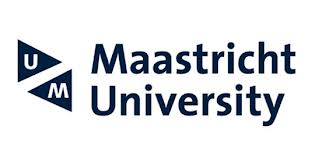

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


By Jan Scholtes

---

Version 2026-2027

---

Welcome to the tutorial on Decoder Models and GPT. In this notebook you will learn about decoder-only Transformer models (the GPT family), explore different text generation strategies, experiment with prompting techniques, and understand the key concepts behind Retrieval Augmented Generation (RAG).

For this notebook we would need our GPU accelerator.

## Learning Goals

After completing this tutorial, you will be able to:

- **Understand** decoder-only Transformer models (GPT family) and how they differ from encoder and encoder-decoder architectures.
- **Explain** the autoregressive generation process and why context length matters.
- **Apply** different text generation (decoding) strategies: greedy, beam search, random sampling, temperature, top-k, and nucleus sampling.
- **Compare** the quality and characteristics of text produced by different decoding strategies.
- **Understand** prompting techniques: zero-shot, few-shot, chain-of-thought, and their impact on model performance.
- **Explain** what Retrieval Augmented Generation (RAG) is and why it helps reduce hallucinations.
- **Discuss** risks, limitations, and ethical considerations of generative language models.

## Decoder-Only Transformer Architecture

In Tutorial 07 (Transformers) and Tutorial 08 (Encoder Models), we explored the full Transformer architecture and encoder-only models like BERT. Now we turn to **decoder-only** models -- the architecture behind the GPT family.

### Key Properties of Decoder-Only Models

- GPT models use **only the decoder** part of the Transformer architecture.
- They are trained with a **left-to-right language modeling objective**: predict the next token given all previous tokens.
- Self-attention is **causal** (masked): each token can only attend to tokens that came before it, not future tokens.
- Generation is **autoregressive**: the model generates one token at a time, feeding each generated token back as input.
- Best suited for **text generation** tasks based on zero/few-shot learning (the "prompt").

### Decoder vs. Encoder vs. Encoder-Decoder

| Architecture | Example Models | Self-Attention | Best For |
|---|---|---|---|
| **Encoder-only** | BERT, RoBERTa | Bidirectional (sees full context) | Classification, NER, Q&A extraction |
| **Decoder-only** | GPT-2/3/4/5 | Causal (left-to-right only) | Text generation, completion, chat |
| **Encoder-Decoder** | T5, BART | Encoder: bidirectional; Decoder: causal | Translation, summarization |

### What happened to the encoder's self-attention?

In decoder-only models, there is no separate encoder. The prompt itself serves as the "context" that the decoder attends to through **causal self-attention**. Every token in the prompt directly expands the self-attention graph, which is why context length matters so much for GPT models.

## Context Length in GPT Models

Context length is critical for decoder-only models because **every token attends to the entire raw history**. This makes cost and memory scale as $O(n^2)$ throughout generation.

### Computational Complexity

**Training**: Each token attends to all previous ones. Cost per layer is approximately $O(n^2 d)$ (attention) + $O(n d^2)$ (FFN), where $n$ is the sequence length and $d$ is the embedding dimension.

**Inference** (autoregressive): To generate $m$ new tokens given a prompt of length $p$:
- First token: attends to $p$ tokens (cost $O(p^2 d)$)
- Each new token $t$ attends to $p + t$ tokens
- Total: approximately $O(m(p + m)d)$

Since you generate one token at a time, you re-run attention over the **entire growing context**. For very long contexts (128k+ tokens in GPT-4), each extra token becomes increasingly expensive.

### Context Sizes Over Time

| Model | Context Window |
|---|---|
| Original Transformer (2017) | 512 tokens |
| GPT-2 (2019) | 1,024 tokens |
| GPT-3 (2020) | 2,048 tokens |
| GPT-4 (2023) | 8k / 128k tokens |
| GPT-5 (2025) | ~400k tokens |

> **Why does this matter?** Encoder-decoder models compress the input once, so decoding does not get exponentially more expensive with long source sequences. GPT-style models must re-attend to everything, making context window size a key design constraint.

## A Brief History of GPT Models

### GPT-1 (June 2018)
- First model to use the decoder part of the Transformer with self-attention for language modeling.
- Trained on the Book Corpus (~7,000 unpublished books).
- Achieved decent zero-shot performance on Q&A and sentiment analysis through pre-training.

### GPT-2 (2019)
- Larger dataset, more parameters.
- Powerful in translation, summarization using just raw text as input with few or no examples.
- OpenAI initially withheld the full model due to concerns about misuse.

### GPT-3 (2020)
- 175 billion parameters -- a breakthrough in scale.
- Could generate paragraphs nearly indistinguishable from human writing.
- Demonstrated strong few-shot learning capabilities.

### ChatGPT (November 30, 2022)
- Built on GPT-3.5, fine-tuned with **Reinforcement Learning from Human Feedback (RLHF)**.
- Major contributions: conversational format, follow-up questions, admitting mistakes, rejecting inappropriate requests.
- Aligned with human values through Supervised Fine-Tuning (SFT) + Reward Model (RM) + Proximal Policy Optimization (PPO).

### GPT-4 (March 2023)
- Multimodal (text + images).
- Human-level performance on professional benchmarks (e.g., top 10% on the bar exam).
- Context window: 8k or 128k tokens.

### GPT-5 (August 2025)
- Enhanced coding and agentic capabilities.
- Context window: up to ~400k tokens (272k input + 128k output).
- Estimated training cost: $100-300 million.

### Other Notable Models
- **Google LaMDA** (2022): Dialogue-focused model (the "sentient AI" controversy)
- **Meta Galactica** (2022): Trained on 48M scientific texts, withdrawn after 3 days due to hallucinations
- **Meta Llama 4** (2025): Mixture-of-Experts architecture, up to ~10M token context claimed
- **Google Gemini 2.5** (2025): Multimodal, up to 1M token context
- **Anthropic Claude 4** (2025): Focus on safety and constitutional AI
- **Mistral** (2025): European open-weight models, efficient MoE architectures

## Text Generation Strategies

GPT models estimate the probability $P(y|x)$ of a sequence of tokens $y = y_1, y_2, \ldots, y_i$ given an initial prompt $x = x_1, x_2, \ldots, x_k$.

This probability is computed as the product of conditional probabilities:

$$P(y|x) = \prod_{t=1}^{i} P(y_t | y_{<t}, x)$$

For each position, the model produces logits $z_{t,i}$ for every token $w_i$ in the vocabulary, and we apply softmax to get probabilities:

$$P(y_t = w_i | y_{<t}, x) = \text{softmax}(z_{t,i})$$

The key question is: **how do we select the next token from this probability distribution?** Different strategies lead to very different text quality and characteristics.

### Overview of Decoding Strategies

| Strategy | Description |
|---|---|
| **Greedy** | Always pick the highest-probability token |
| **Beam Search** | Maintain top-k candidate sequences |
| **Random Sampling** | Sample from the distribution |
| **Temperature** | Control the sharpness of the distribution |
| **Top-K Sampling** | Sample from the K most likely tokens |
| **Nucleus (Top-p)** | Sample from the smallest set of tokens whose cumulative probability exceeds p |

Let's experiment with all of these using GPT-2.

In [ ]:
# Install requirements
import importlib, subprocess, sys
to_install = [p for p, m in [('transformers', 'transformers'), ('torch', 'torch')]
              if importlib.util.find_spec(m) is None]
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])


In [ ]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

# Load GPT-2 model and tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()

# Set pad token (GPT-2 doesn't have one by default)
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

print(f"Model loaded: {model.config.n_layer} layers, {model.config.n_head} heads, {model.config.n_embd} embedding dim")
print(f"Vocabulary size: {model.config.vocab_size}")
print(f"Context window: {model.config.n_positions} tokens")

### Greedy Search

Greedy decoding simply selects the token with the highest probability at each step. It is fast but can produce repetitive and bland text, often getting stuck in loops.

$$y_t = \arg\max_{w} P(w | y_{<t}, x)$$

In [ ]:
prompt = "The future of artificial intelligence is"
input_ids = tokenizer.encode(prompt, return_tensors='pt')

# Greedy decoding (default: do_sample=False, num_beams=1)
output = model.generate(
    input_ids,
    max_new_tokens=100,
    do_sample=False,
    num_beams=1
)

print("=== Greedy Search ===")
print(tokenizer.decode(output[0], skip_special_tokens=True))

### Beam Search

Beam search maintains $k$ candidate sequences (beams) at each step and selects the sequence with the highest overall probability. It produces better results than greedy but can still be repetitive.

An **n-gram penalty** can be added to prevent repeated phrases: if generating a token would create an n-gram already seen, its probability is set to zero.

In [ ]:
# Beam search with 5 beams
output_beam = model.generate(
    input_ids,
    max_new_tokens=100,
    num_beams=5,
    no_repeat_ngram_size=2,  # Prevent repeating any 2-gram
    early_stopping=True
)

print("=== Beam Search (5 beams, no 2-gram repeat) ===")
print(tokenizer.decode(output_beam[0], skip_special_tokens=True))

### Random Sampling and Temperature

**Random sampling** draws the next token from the probability distribution rather than always picking the argmax. This introduces creativity but can also produce incoherent text.

**Temperature** ($T$) controls the sharpness of the distribution before sampling:

$$P(y_t = w_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

- $T < 1$: Sharper distribution (more deterministic, less creative)
- $T = 1$: Original distribution
- $T > 1$: Flatter distribution (more random, more creative)

In [ ]:
# Compare different temperatures
for temp in [0.3, 0.7, 1.0, 1.5]:
    output_temp = model.generate(
        input_ids,
        max_new_tokens=80,
        do_sample=True,
        temperature=temp,
        top_k=0,  # Disable top-k to see pure temperature effect
    )
    print(f"=== Temperature = {temp} ===")
    print(tokenizer.decode(output_temp[0], skip_special_tokens=True))
    print()

### Top-K Sampling

Top-K sampling restricts the candidate tokens to the $K$ most probable ones. This prevents the model from selecting very unlikely tokens while still maintaining diversity.

Less probable tokens have no chance at all, reducing "weird" model behavior.

In [ ]:
# Top-K sampling
for k in [5, 20, 50]:
    output_topk = model.generate(
        input_ids,
        max_new_tokens=80,
        do_sample=True,
        top_k=k,
        temperature=0.8,
    )
    print(f"=== Top-K = {k} ===")
    print(tokenizer.decode(output_topk[0], skip_special_tokens=True))
    print()

### Nucleus (Top-p) Sampling

Nucleus sampling selects the smallest set of tokens whose cumulative probability is at least $p$. This adaptively adjusts the number of candidate tokens:
- When the model is confident, the set is small (few candidates).
- When the model is uncertain, the set is larger (more candidates).

This avoids the fixed-K problem of top-K sampling, where K might be too large (including unlikely tokens) or too small (limiting diversity) depending on context.

In [ ]:
# Nucleus sampling
for p in [0.5, 0.9, 0.95]:
    output_nucleus = model.generate(
        input_ids,
        max_new_tokens=80,
        do_sample=True,
        top_p=p,
        top_k=0,  # Disable top-k to see pure nucleus effect
        temperature=0.8,
    )
    print(f"=== Nucleus p = {p} ===")
    print(tokenizer.decode(output_nucleus[0], skip_special_tokens=True))
    print()

### Summary of Decoding Strategies

| Strategy | Pros | Cons |
|---|---|---|
| **Greedy** | Fast, deterministic | Repetitive, misses better sequences |
| **Beam Search** | Better global sequences | Still repetitive, expensive |
| **Random Sampling** | Creative, diverse | Can be incoherent |
| **Temperature** | Controls creativity | Extreme values produce garbage |
| **Top-K** | Removes unlikely tokens | Fixed K may not suit all contexts |
| **Nucleus (Top-p)** | Adaptive token set | Slightly more complex |

In practice, most production systems use a **combination**: nucleus sampling with a moderate temperature (e.g., top_p=0.9, temperature=0.7) produces the best balance of quality and diversity. ChatGPT and similar systems use variations of these strategies.

## Prompting Techniques

Since we typically cannot retrain or fine-tune large proprietary models like GPT-4, **prompting** is the primary way to control their behavior. The quality of the output depends heavily on how we formulate the input.

### Enriching a Prompt

Several strategies can improve prompt quality:
- **Context**: Provide documents, websites, or background information
- **Focus**: "Focus only on advantages/disadvantages", "Limit yourself to legal implications"
- **Impersonation**: "Write for a layman / an expert / freshmen / judges"
- **Examples**: Provide input-output pairs
- **Style and tone**: "Write formally/informally", "Use a scientific tone"
- **Structure**: "List the output", "Use subheadings and paragraphs"
- **Constraints**: "Use a maximum of 200 words", "Avoid professional jargon" 

### Zero-Shot, One-Shot, and Few-Shot Prompting

**Zero-shot**: The model is asked to perform a task without any examples -- relying entirely on its pre-trained knowledge and clear instructions.

**One-shot**: A single example is provided alongside the instruction, helping the model understand the desired format and task.

**Few-shot**: Three to five examples are provided, helping the model solve complex problems more accurately by showing multiple task variations.

The more examples provided, the more reliable the output tends to be -- but at the cost of using more of the context window.

In [ ]:
from transformers import pipeline

# Use GPT-2 for demonstration (in practice, you'd use GPT-4 or similar)
generator = pipeline('text-generation', model='gpt2', device=-1)

# Zero-shot
zero_shot_prompt = """Classify the sentiment of the following text as positive or negative.
Text: "The movie was absolutely wonderful and I loved every minute of it."
Sentiment:"""

result = generator(zero_shot_prompt, max_new_tokens=5, do_sample=False)
print("=== Zero-Shot ===")
print(result[0]['generated_text'])
print()

# Few-shot
few_shot_prompt = """Classify the sentiment of each text.

Text: "I love this product, it works perfectly!" -> Positive
Text: "Terrible experience, would not recommend." -> Negative
Text: "The food was amazing and the service was great." -> Positive
Text: "The movie was boring and too long." ->"""

result = generator(few_shot_prompt, max_new_tokens=5, do_sample=False)
print("=== Few-Shot ===")
print(result[0]['generated_text'])

### Chain of Thought (CoT) Prompting

Chain-of-thought prompting encourages the model to break down complex problems into step-by-step reasoning within a single prompt. This is particularly effective for tasks requiring logical reasoning, arithmetic, or multi-step analysis.

### Tree of Thought (ToT) Prompting

Tree-of-thought extends CoT by exploring **multiple reasoning paths** simultaneously, like a decision tree. The model:
1. **Decomposes** the problem into smaller steps
2. **Generates** multiple candidate solutions at each step
3. **Evaluates** each path (by value scoring or voting)
4. **Searches** using BFS or DFS to find the best solution

### Skeleton of Thought (SoT) Prompting

SoT focuses on **efficiency**: first generate a high-level outline (the "skeleton"), then expand each point into full explanations. This reduces verbosity while maintaining structured reasoning.

## Reinforcement Learning from Human Feedback (RLHF)

Raw decoder-only models (GPT-2, GPT-3) are trained to predict the next token. This means they are good at generating *plausible* text, but not necessarily *helpful*, *truthful*, or *safe* text. A model trained only on next-token prediction might:
- Generate toxic or biased content (it learned from the internet)
- Produce confident-sounding but factually wrong statements (hallucinations)
- Not follow instructions well (it's a text completer, not an assistant)

**RLHF** is the key technique that transforms a base language model into a useful assistant (like ChatGPT). It works in three stages:

### Stage 1: Supervised Fine-Tuning (SFT)
Fine-tune the base model on high-quality (prompt, response) pairs written by human annotators. This teaches the model the *format* of helpful responses.

### Stage 2: Reward Model Training
1. For many prompts, generate **multiple responses** from the SFT model
2. Human annotators **rank** these responses from best to worst
3. Train a separate **reward model** (RM) to predict human preferences — given a (prompt, response) pair, it outputs a scalar score

### Stage 3: PPO (Proximal Policy Optimization)
1. The SFT model generates responses to new prompts
2. The reward model scores each response
3. The model is updated using **reinforcement learning** (PPO algorithm) to maximize the reward score
4. A **KL penalty** prevents the model from drifting too far from the SFT model (to avoid reward hacking — generating nonsensical text that exploits the reward model)

### Why RLHF Matters

| Without RLHF | With RLHF |
|---|---|
| Completes text plausibly | Follows instructions |
| May generate harmful content | Refuses harmful requests |
| Hallucinates confidently | More calibrated, says "I don't know" |
| Verbose, unfocused | Concise, relevant answers |

### Alternatives to RLHF
- **DPO** (Direct Preference Optimization): Skips the reward model, directly optimizes the LLM from preference pairs. Simpler and increasingly popular.
- **Constitutional AI** (Anthropic): The model critiques and revises its own outputs based on a set of principles, reducing the need for human annotators.
- **RLAIF** (RL from AI Feedback): Uses another LLM as the reward model instead of human annotators.

## Retrieval Augmented Generation (RAG)

### Why RAG?

LLMs are trained on massive corpora, but their parameters are **fixed after training**. This means:
- They only "know" what was in the training data up to their cutoff date
- They have a finite context window -- they cannot hold entire libraries in memory
- They may **hallucinate** when asked about rare or new facts
- They cannot update knowledge without retraining

RAG is like a student consulting a textbook to write a paper rather than writing from memory.

### How RAG Works

RAG gives LLMs a **working memory** (via retrieval) and an **updatable knowledge base** (via external documents):

1. **Query**: The user's question or prompt
2. **Retrieve**: Search external documents/databases for relevant information
3. **Augment**: Insert the retrieved context into the prompt
4. **Generate**: The LLM generates a response grounded in the retrieved facts

### Fusion Methods

| Level | Method | Description |
|---|---|---|
| **Prompt Level** (Early Fusion) | Text Concatenation | Append retrieved text to the prompt |
| **Vector Level** (Embedding Fusion) | Query Expansion, Vector Fusion | Merge query and document embeddings |
| **KG-based** | KG Triples as Text/Embeddings | Inject knowledge graph triples |
| **Late Fusion** | Cross-attention, Re-ranking | Cross-attention over retrieved documents |
| **Memory-Augmented** | kNN-LM, RETRO | Retrieval as external memory |
| **Dynamic Decoding** | Dynamic Retrieval | Retrieve during generation |

RAG is essential for high-stakes applications (legal, medical) where factual accuracy is critical. We will explore RAG in more detail in the course IRTM.

## Mixture of Experts (MoE) and Mixture of Models (MoM)

### Mixture of Experts (MoE)

Inside a single model, MoE uses many "expert" feed-forward blocks. A **router network** decides for each token which 1-2 experts to activate. All experts share the same input/output embedding space.

**Goal**: Save compute by only using a fraction of parameters per token while having very large total capacity.

**Example**: Mixtral 8x7B has 8 feed-forward "experts" (~7B params each). Only 2 are active per token, so inference costs ~14B FLOPs/token while total capacity is ~56B.

### Mixture of Models (MoM)

A higher-level orchestrator decides which **separate, complete models** to call or combine. Each "expert" is an entire LLM with its own weights and training.

**Example**: A chatbot that first tries a small cheap model, escalates to GPT-5 if uncertain, and calls a specialized code model for Python snippets.

| Aspect | MoE | MoM |
|---|---|---|
| **Experts** | Sub-networks inside one model | Separate stand-alone models |
| **Routing** | Learned gating layer (per token) | External controller (per request) |
| **Training** | Jointly trained end-to-end | Each model trained separately |
| **Deployment** | One combined model | System of multiple models |

## Risks, Limitations, and Ethical Considerations

### The "Stochastic Parrot" Critique

Stand-alone LLMs have been described as "stochastic parrots" -- they have no knowledge, no memory, no understanding, and no consciousness. They are sophisticated next-word predictors kicked off with a prompt. The longer the generated text, the higher the probability of nonsense.

### What ChatGPT Was NOT Designed For
- Knowledge storage and memory
- Factuality verification
- Mathematical reasoning
- Awareness or consciousness

### Key Risks

**Hallucinations**: LLMs confidently generate false information. This is particularly dangerous in legal, medical, and financial applications.

**Misinformation and Misuse**: LLMs can generate fake news, phishing emails, fraudulent academic essays, and social engineering attacks at scale. Models like FraudGPT and WormGPT have been specifically created for malicious purposes.

**Sycophantic Behavior**: Models tend to agree with users and tell them what they want to hear, even at the cost of accuracy. OpenAI has had to roll back updates that made models "overly flattering."

**Prompt Injection**: Adversaries can embed hidden instructions in inputs (e.g., white text in resumes) to manipulate AI screeners.

**Data Quality and Model Collapse**: Training AI on AI-generated text leads to "model collapse" -- output becomes gibberish. AI needs fresh human input for perspective.

**Environmental Cost**: Training large models requires enormous energy. Training GPT-4 is estimated to have cost $100M+ in compute alone.

**Lack of Transparency**: GPT-2 was open source, GPT-3 had published architecture details, but GPT-4/5 provide almost no information about their internals. Less transparency means more risk.

**Copyright Issues**: Multiple lawsuits challenge the use of copyrighted material in training data.

**Labor Exploitation**: The human annotation work needed to align models (e.g., labeling toxic content) is often outsourced to low-wage workers in developing countries.

## Take Away

### Key Concepts

1. **Decoder-only models** (GPT family) use causal self-attention and autoregressive generation. They excel at text generation but context length has $O(n^2)$ computational cost.

2. **Decoding strategies** (greedy, beam search, sampling, temperature, top-k, nucleus) each have trade-offs between quality, diversity, and computational cost. Most production systems use nucleus sampling with moderate temperature.

3. **Prompting** (zero-shot, few-shot, CoT, ToT, SoT) is the primary way to control proprietary LLMs. Better prompts lead to dramatically better outputs.

4. **RAG** bridges the gap between static pre-trained knowledge and real-world facts by retrieving external information at inference time.

5. **MoE/MoM** enable scaling model capacity without proportionally scaling compute.

6. **Risks** include hallucinations, misinformation, sycophancy, environmental cost, and lack of transparency. These must be actively mitigated in production systems.

### Methods to Improve LLM Performance

| Method | Access Required | Effectiveness |
|---|---|---|
| Better prompting | None (API) | High |
| RAG | None (API) | Very high for factuality |
| MoE/MoM | Architecture level | High for efficiency |
| Domain-specific fine-tuning | Open-source model | Very high |
| RLHF | Open-source model | High for alignment |

> In the next tutorial, we will explore **XAI (Explainable AI) for NLP** -- techniques to understand *why* these models make the predictions they do.

# Exercises

## Exercise A1: Comparing Decoding Strategies (25 points)

**Task**: Using GPT-2, generate text from the same prompt using **four different decoding strategies** and compare the results.

1. Use the prompt: `"Climate change is one of the greatest challenges facing humanity because"`
2. Generate at least 100 tokens with each of these strategies:
   - Greedy search
   - Beam search (5 beams, with 2-gram repetition penalty)
   - Top-k sampling (k=50, temperature=0.8)
   - Nucleus sampling (p=0.92, temperature=0.7)
3. Store the four generated texts in a dictionary called `results` with keys: `"greedy"`, `"beam"`, `"topk"`, `"nucleus"`.
4. Print each result with a header showing the strategy name.

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A1 (20 points)
assert isinstance(results, dict), "results must be a dictionary"
assert set(results.keys()) == {"greedy", "beam", "topk", "nucleus"}, \
    f"results must have keys 'greedy', 'beam', 'topk', 'nucleus', got {set(results.keys())}"

for key, text in results.items():
    assert isinstance(text, str), f"results['{key}'] must be a string"
    assert len(text) > len(prompt), f"results['{key}'] must be longer than the prompt"
    assert text.startswith(prompt[:20]), f"results['{key}'] must start with the prompt"

# Check that different strategies produce different outputs
unique_outputs = set(results.values())
assert len(unique_outputs) >= 2, "Different strategies should produce different outputs"

print("All tests passed!")
for key in results:
    print(f"  {key}: {len(results[key])} chars")

**Compare the four outputs:**

1. Which strategy produces the most repetitive text? Why?
2. Which strategy produces the most creative/diverse text? Why?
3. Which output would you consider the "best" for a factual article? For creative writing? Justify your choices.

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Prompting Techniques (15 points)

In this exercise, you will explore how different prompting strategies affect model output for a classification task.

**Task**: Using the Hugging Face `text-generation` pipeline with GPT-2:

1. Create a **zero-shot prompt** that asks the model to classify a restaurant review as positive, negative, or neutral.
2. Create a **few-shot prompt** (with at least 3 examples) for the same task.
3. Store your prompts in variables `zero_shot_prompt` and `few_shot_prompt`.
4. Generate outputs for both and store them in `zero_shot_result` and `few_shot_result`.

Use this test review: `"The pasta was overcooked but the dessert made up for it."`

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A2 (10 points)
assert isinstance(zero_shot_prompt, str), "zero_shot_prompt must be a string"
assert isinstance(few_shot_prompt, str), "few_shot_prompt must be a string"
assert test_review in zero_shot_prompt, "zero_shot_prompt must contain the test review"
assert test_review in few_shot_prompt, "few_shot_prompt must contain the test review"

# Check that few-shot has examples
assert few_shot_prompt.count('->') >= 3, "few_shot_prompt must have at least 3 examples (marked with ->)"

assert isinstance(zero_shot_result, str), "zero_shot_result must be a string"
assert isinstance(few_shot_result, str), "few_shot_result must be a string"

print("All tests passed!")
print(f"Zero-shot prompt length: {len(zero_shot_prompt)} chars")
print(f"Few-shot prompt length: {len(few_shot_prompt)} chars")

**Compare zero-shot and few-shot results:**

1. Did the few-shot prompt produce a more accurate classification than zero-shot? Why or why not?
2. What are the trade-offs of using few-shot prompting in terms of context window usage?
3. How would Chain-of-Thought prompting differ from few-shot for this task? Write an example CoT prompt.

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Risks, RAG, and Responsible AI (15 points)

Answer the following questions:

**a)** Explain the concept of **hallucination** in LLMs. Why do decoder-only models hallucinate, and how does RAG specifically address this problem? Describe the RAG pipeline step by step.

**b)** The lecture discussed the **"stochastic parrot" critique** of LLMs. Do you agree or disagree with this characterization? Provide at least two arguments for and two against. Consider the impact of techniques like RAG and CoT prompting on this debate.

**c)** A hospital wants to deploy a GPT-based system to help doctors write patient discharge summaries. Identify **three specific risks** this application faces and propose a concrete mitigation strategy for each risk.

**d)** (5 points) Explain how RLHF works step by step (3 stages). Why is it critical for making decoder-only models useful as chatbots? What would happen without it?

### BEGIN SOLUTION

**a)** Hallucination occurs when an LLM generates text that sounds plausible but is factually incorrect. Decoder-only models hallucinate because they are trained to predict the *most likely next token* based on statistical patterns in training data -- they have no mechanism to verify facts against reality. If a pattern of words seems statistically likely, the model will generate it regardless of truth.

**RAG pipeline step by step**:
1. **Query formulation**: The user's question is processed (possibly reformulated) into a search query.
2. **Retrieval**: The query is used to search an external knowledge base (document store, vector database, or knowledge graph) for relevant passages. This typically uses dense retrieval (embedding similarity) or sparse retrieval (BM25).
3. **Context augmentation**: The retrieved passages are inserted into the prompt alongside the original question, typically with instructions like "Answer based on the following context."
4. **Generation**: The LLM generates a response grounded in the retrieved context rather than relying solely on parametric memory.
5. **Optional post-processing**: Some systems verify the generated answer against the retrieved sources or add citations.

RAG addresses hallucination by providing the model with factual, up-to-date information at inference time, reducing reliance on potentially outdated or incorrect parametric knowledge.

**b)** Arguments **for** the "stochastic parrot" characterization:
1. LLMs have no world model or grounding -- they manipulate token probabilities without understanding meaning. They can confidently assert contradictory facts in different prompts.
2. They cannot verify their own outputs or distinguish truth from plausible-sounding falsehoods, which is fundamentally different from understanding.

Arguments **against**:
1. Emergent capabilities (few-shot learning, chain-of-thought reasoning, code generation) suggest something beyond simple pattern matching. The ability to generalize to unseen tasks was not explicitly trained.
2. With techniques like RAG (external knowledge), CoT (structured reasoning), and tool use (calculators, search engines), LLMs can produce reliably accurate outputs. The "parrot" characterization ignores the system-level capabilities when LLMs are embedded in larger architectures.

**c)** Three risks for a hospital discharge summary system:

1. **Hallucinated medical information**: The system might generate incorrect medication dosages, fabricated lab results, or wrong diagnoses.
   - *Mitigation*: Implement RAG that retrieves from the patient's actual medical record (EHR). Add a verification layer that cross-checks generated medication names and dosages against the hospital's pharmacy database. Require physician review before finalization.

2. **Privacy and data leakage**: The model might include information from other patients' records in training data, or the prompt/completion could be logged by third-party API providers.
   - *Mitigation*: Deploy a locally-hosted, fine-tuned model (not a cloud API) within the hospital's secure infrastructure. Apply de-identification to all inputs and outputs. Ensure compliance with HIPAA/GDPR through data processing agreements.

3. **Automation bias**: Doctors might over-rely on the AI-generated summaries and miss errors, especially under time pressure.
   - *Mitigation*: Design the UI to present the AI output as a "draft" requiring active editing, not a finished document. Highlight sections with low confidence scores. Implement mandatory checkboxes for critical items (allergies, medication changes) that force physician verification.

### END SOLUTION

**d) RLHF (Reinforcement Learning from Human Feedback)**

RLHF has three stages:
1. **Supervised Fine-Tuning (SFT)**: Fine-tune the base model on curated (prompt, response) pairs to teach it the assistant format.
2. **Reward Model Training**: Generate multiple responses per prompt, have humans rank them, and train a reward model to predict human preferences.
3. **PPO Optimization**: Use the reward model as a signal to update the LLM via reinforcement learning (PPO), with a KL penalty to prevent reward hacking.

Without RLHF, decoder-only models are just text completers — they generate plausible continuations but don't follow instructions, may produce harmful content, and hallucinate confidently. RLHF aligns the model with human preferences for helpfulness, harmlessness, and honesty. It's the difference between GPT-3 (text completer) and ChatGPT (assistant).
YOUR ANSWER HERE


## References

- GPT-2: Radford, A., Wu, J., Child, R., Luan, D., Amodei, D. & Sutskever, I. "Language Models are Unsupervised Multitask Learners." (2019).
- GPT-3: Brown, T.B. et al. "Language Models are Few-Shot Learners." arXiv:2005.14165, July 2020.
- ChatGPT: Ouyang, L. et al. "Training language models to follow instructions with human feedback." NeurIPS 35, 27730-27744. March 2022.
- GPT-4: OpenAI. "GPT-4 Technical Report." https://arxiv.org/abs/2303.08774
- Holtzman, A. et al. "The Curious Case of Neural Text Degeneration." ICLR 2020.
- Wei, J. et al. "Chain of Thought Prompting Elicits Reasoning in Large Language Models." https://arxiv.org/abs/2201.11903
- Yao, S. et al. "Tree of Thoughts: Deliberate Problem Solving with Large Language Models." https://arxiv.org/abs/2305.10601
- Lewis, P. et al. "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks." NeurIPS 2020.
- Bender, E.M. et al. "On the Dangers of Stochastic Parrots: Can Language Models Be Too Big?" FAccT 2021.